In [1]:
import pandas as pd

In [115]:
df=pd.read_csv("perfume.csv")

In [116]:
df = df.drop_duplicates(keep=False)
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
6,light,6.2,0.32,0.16,7.00,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6
9,light,8.1,0.22,0.43,1.50,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6
10,light,8.1,0.27,0.41,1.45,0.033,11.0,63.0,0.9908,2.99,0.56,12.0,5
11,light,8.6,0.23,0.40,4.20,0.035,17.0,109.0,0.9947,3.14,0.53,9.7,5
12,light,7.9,0.18,0.37,1.20,0.040,16.0,75.0,0.9920,3.18,0.63,10.8,5


In [117]:
df.isna().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [118]:
df.duplicated().sum()

np.int64(0)

In [119]:
df.dropna(inplace=True)

<Axes: xlabel='fixed acidity'>

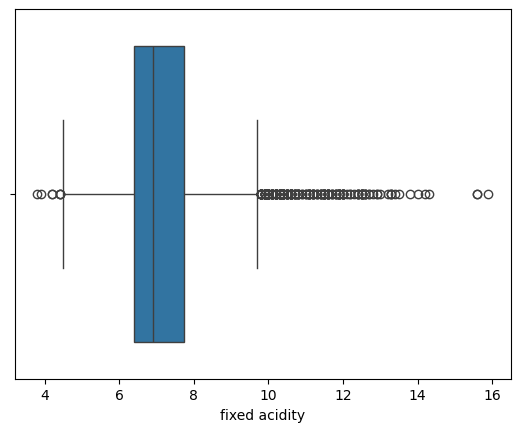

In [120]:
import seaborn as sns
sns.boxplot(df,x='fixed acidity')

<Axes: xlabel='fixed acidity'>

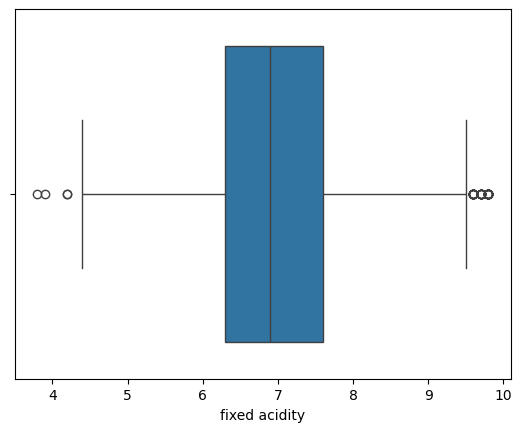

In [121]:
df=df[df['fixed acidity']<df['fixed acidity'].quantile(0.95)]
sns.boxplot(df,x='fixed acidity')

<Axes: xlabel='volatile acidity'>

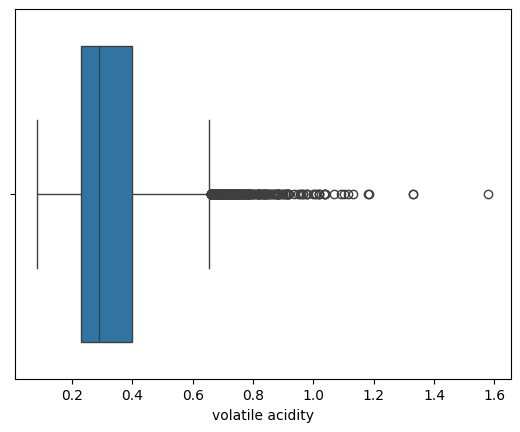

In [20]:
sns.boxplot(df,x='volatile acidity')


<Axes: xlabel='volatile acidity'>

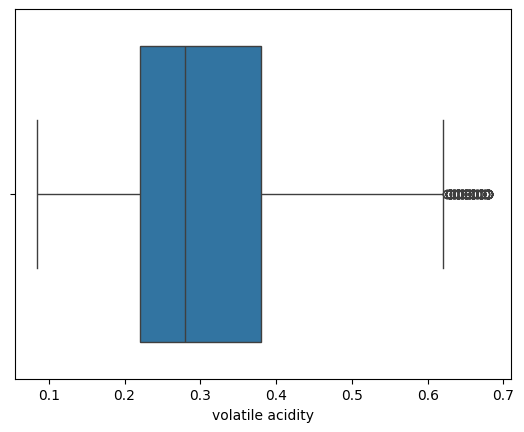

In [21]:
df=df[df['volatile acidity']<df['volatile acidity'].quantile(0.95)]
sns.boxplot(df,x='volatile acidity')

<Axes: xlabel='citric acid'>

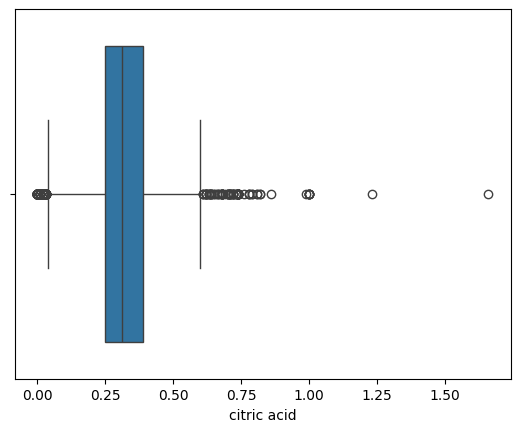

In [22]:
sns.boxplot(df,x='citric acid')

<Axes: xlabel='citric acid'>

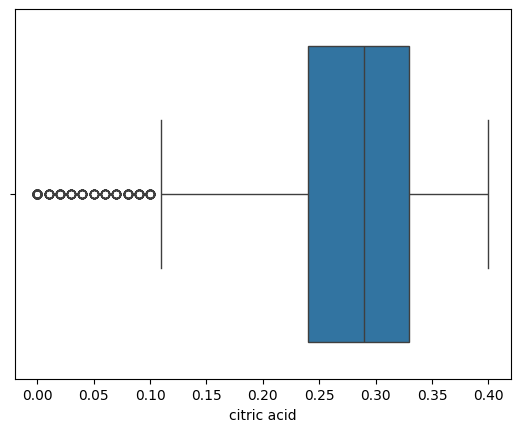

In [26]:
df=df[df['citric acid']<df['citric acid'].quantile(0.95)]
sns.boxplot(df,x='citric acid')

<Axes: xlabel='residual sugar'>

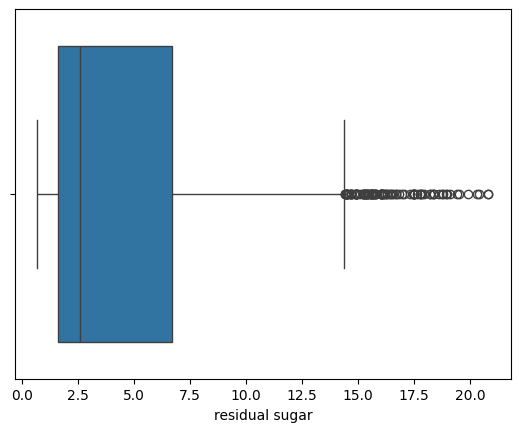

In [27]:
sns.boxplot(df,x='residual sugar')

<Axes: xlabel='residual sugar'>

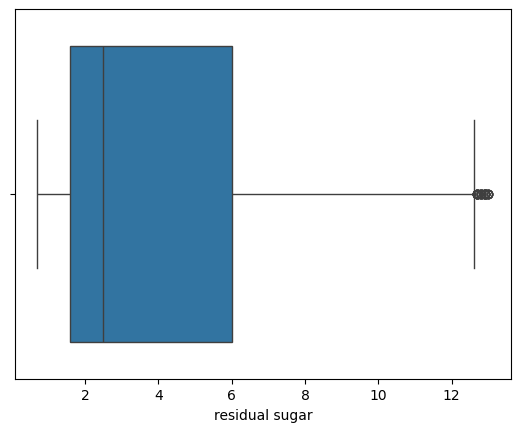

In [28]:
df=df[df['residual sugar']<df['residual sugar'].quantile(0.95)]
sns.boxplot(df,x='residual sugar')

<Axes: xlabel='chlorides'>

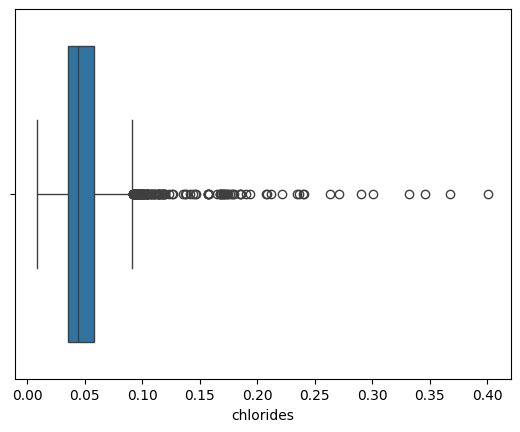

In [29]:
sns.boxplot(df,x='chlorides')

<Axes: xlabel='chlorides'>

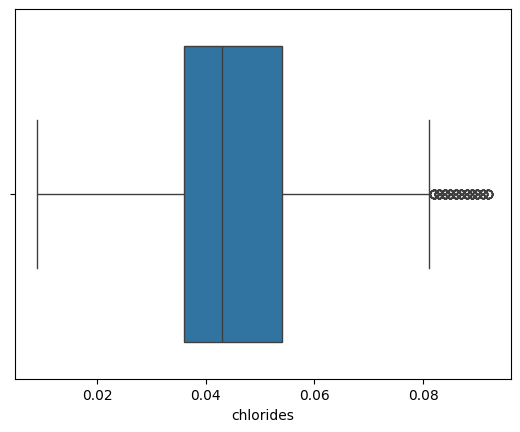

In [30]:
df=df[df['chlorides']<df['chlorides'].quantile(0.95)]
sns.boxplot(df,x='chlorides')

<Axes: xlabel='free sulfur dioxide'>

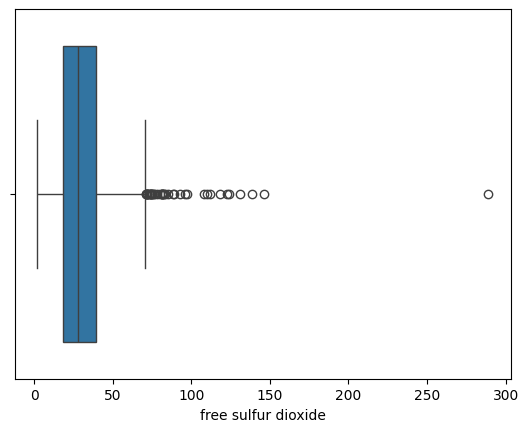

In [31]:
sns.boxplot(df,x='free sulfur dioxide')

<Axes: xlabel='free sulfur dioxide'>

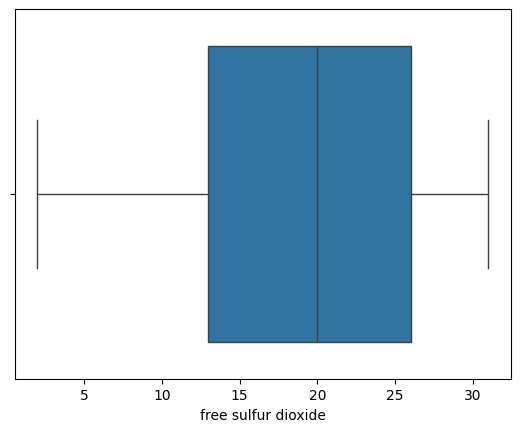

In [36]:
df=df[df['free sulfur dioxide']<df['free sulfur dioxide'].quantile(0.95)]
sns.boxplot(df,x='free sulfur dioxide')

<Axes: xlabel='total sulfur dioxide'>

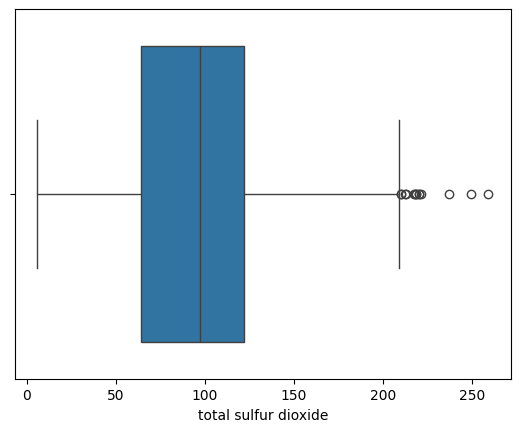

In [37]:
sns.boxplot(df,x='total sulfur dioxide')

<Axes: xlabel='total sulfur dioxide'>

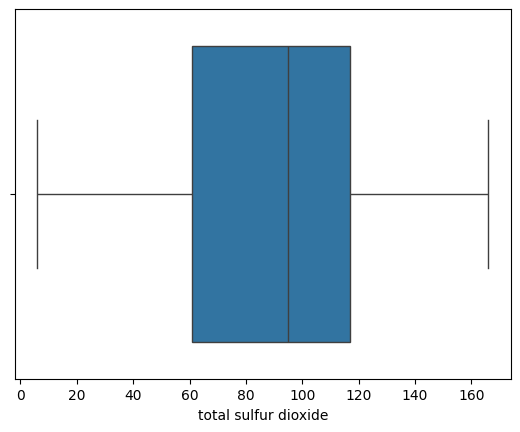

In [38]:
df=df[df['total sulfur dioxide']<df['total sulfur dioxide'].quantile(0.95)]
sns.boxplot(df,x='total sulfur dioxide')

<Axes: xlabel='density'>

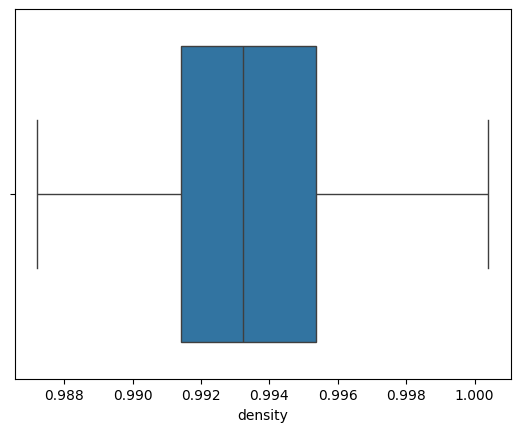

In [39]:
sns.boxplot(df,x='density')

<Axes: xlabel='pH'>

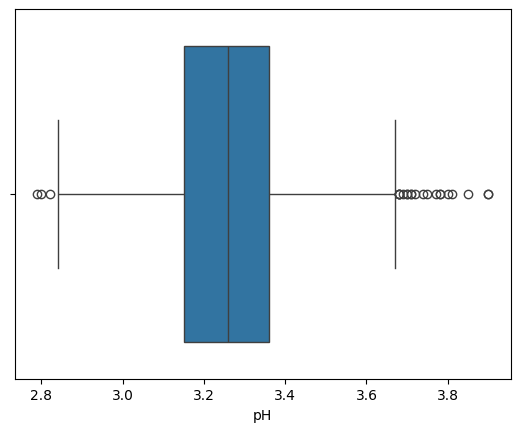

In [41]:
sns.boxplot(df,x='pH')

<Axes: xlabel='pH'>

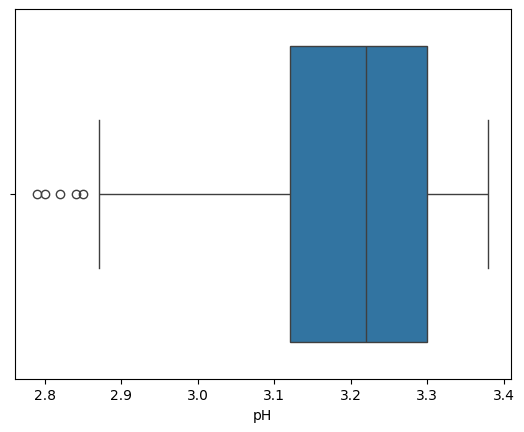

In [44]:
df=df[df['pH']<df['pH'].quantile(0.95)]
sns.boxplot(df,x='pH')

<Axes: xlabel='sulphates'>

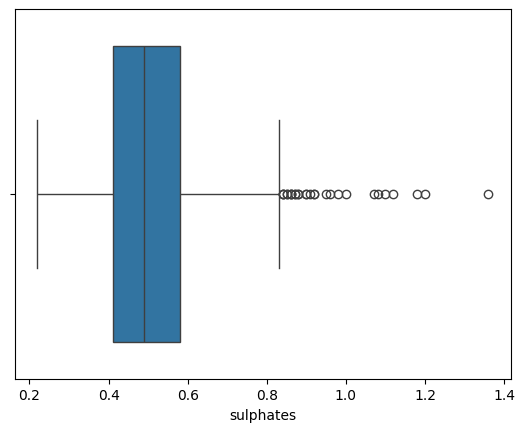

In [45]:
sns.boxplot(df,x='sulphates')

<Axes: xlabel='sulphates'>

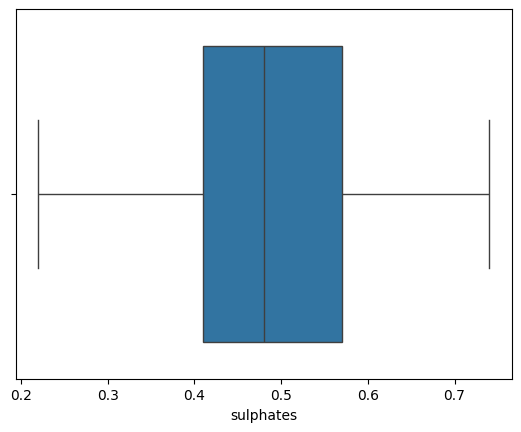

In [46]:
df=df[df['sulphates']<df['sulphates'].quantile(0.95)]
sns.boxplot(df,x='sulphates')

<Axes: xlabel='alcohol'>

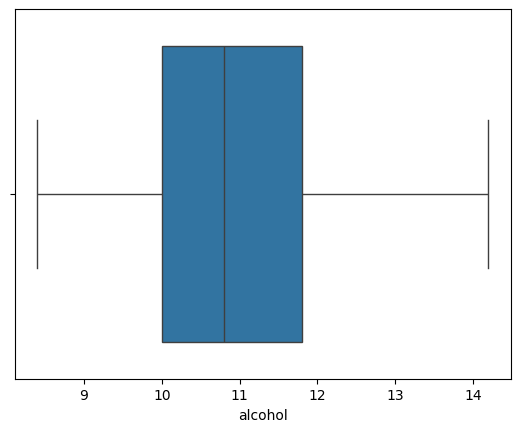

In [47]:
sns.boxplot(df,x='alcohol')

<Axes: xlabel='quality'>

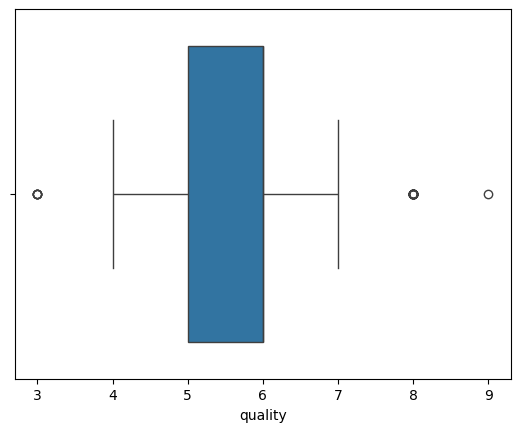

In [48]:
sns.boxplot(df,x='quality')

<Axes: xlabel='quality'>

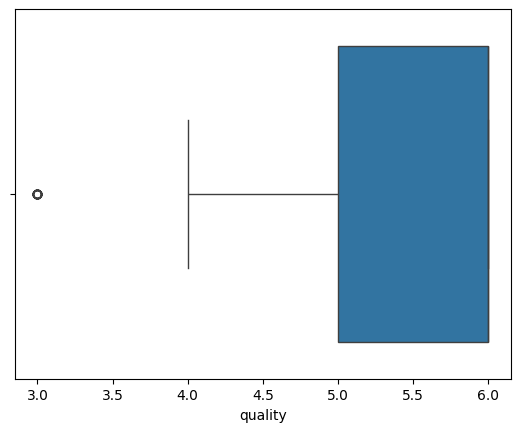

In [79]:
df=df[df['quality']<df['quality'].quantile(0.95)]
sns.boxplot(df,x='quality')

<Axes: xlabel='quality'>

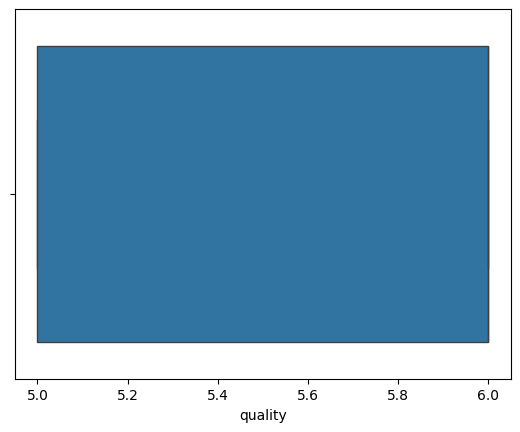

In [81]:
df=df[df['quality']>df['quality'].quantile(0.05)]
sns.boxplot(df,x='quality')

In [90]:
df['quality'].unique()

array([6, 5])

In [122]:
df['type']=df['type'].map({'strong':1, 'light': 0})

In [123]:
X = df.drop('type',axis=1)

In [124]:
y = df['type']

In [125]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [126]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [127]:
from sklearn.linear_model import Ridge, LogisticRegression, Lasso
import numpy as np
model= Ridge()
params={
    'alpha': np.logspace(-3,1, num=50)
}

In [128]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(model,params,cv=10)
grid.fit(X_train_sc,y_train)

,estimator,Ridge()
,param_grid,{'alpha': array([1.0000...00000000e+01])}
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(10.0)


In [129]:
model = grid.best_estimator_

In [130]:
ypred = model.predict(X_test_sc)

In [131]:
ypred

array([-1.26273018e-01,  3.43084668e-02,  7.89939977e-01, -8.07129884e-03,
        2.79171177e-02,  1.94220666e-01,  6.14225767e-01, -3.89948426e-02,
        9.29748853e-02,  1.18270319e+00,  7.81067142e-03,  6.42109725e-01,
        1.09889162e+00, -1.62205949e-01, -3.53645064e-02, -4.83033832e-02,
        9.07374242e-01,  6.61686187e-01, -3.24586524e-01,  2.68749824e-01,
        9.97503402e-01, -1.42415246e-01, -5.07500577e-03,  7.97026001e-02,
        5.07041608e-02, -4.22266804e-02, -3.72179250e-02,  7.14737309e-02,
        1.38168629e-01, -1.33952330e-01,  9.85271708e-01, -2.36370509e-02,
       -2.32081897e-01, -1.90569512e-02, -1.75860769e-01, -2.47733261e-02,
        7.63637672e-01,  1.15744051e-01, -6.79671098e-02,  1.43623228e-01,
        2.70317890e-02,  5.03714309e-03,  1.13785211e+00,  1.15596532e-01,
       -3.32686084e-02,  2.29293927e-01,  2.20214585e-01,  6.07471460e-02,
        1.41165743e+00, -6.94603359e-02, -3.23433316e-02,  1.09780280e+00,
       -1.47909912e-01, -

In [132]:
from sklearn.metrics import r2_score

In [133]:
print(r2_score(y_test,ypred))

0.831107709383677
